# Analyse cocktail entropy and enthalpy

In [1]:
import os
import sys
import torch
from itertools import product
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utils_mean_field import *
from script_mean_field_covid import *

main_path = "../"

sys.path.append(main_path + "PGM/source/")
sys.path.append(main_path + "PGM/utilities/")
import utilities, Proteins_utils, sequence_logo, plots_utils
sys.path.append(main_path + "covid/")
os.chdir(main_path + "covid/")

from global_variables import *
# from AB_RBM_EnergyModel import *
# from utils_evaluate_seq import *
os.chdir('../mean_field_theory')
os.listdir()

e:\ESCAPE_PATHS\covid\../PGM/source\numba_utilities.py:1036: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 1, 'A', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  mean_V = np.dot(weights, V) / sum_weights
e:\ESCAPE_PATHS\covid\../PGM/source\numba_utilities.py:1322: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 2, 'F', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  dmean_v_dw = np.dot(s1.T, V)
C:\Users\maria\AppData\Roaming\Python\Python312\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


Loaded 29 KD vectors


['cocktail_beta_analysis.ipynb',
 'covid_D_21',
 'covid_mf_analysis.ipynb',
 'covid_mf_entropy.ipynb',
 'covid_mf_projection.ipynb',
 'D_10_cocktail_beta_summary.csv',
 'script_cocktail_analysis.py',
 'script_get_proba.py',
 'script_mean_field_cocktail_covid.py',
 'script_mean_field_covid.py',
 'utils_mean_field.py',
 'utils_rbm_mean_field.py',
 '__pycache__']

In [2]:
PROT_INIT = Proteins_utils.load_FASTA("../covid/exp_data/wt_omicron.fasta")[0]
PROT_INIT = PROT_INIT[BEGIN:-END]


In [3]:
L=PROT_INIT.shape[0]
Q = 20






# Entropy and energy for each cocktail

In [6]:
df=pd.read_csv("D_10_cocktail_beta_summary.csv")
df['rbm']=(df['zeta_gamma']+df['field_energy'])*L
df['phi']=(df['phi'])*L
df['entropy']=(df['entropy'])*L

df

,beta_ab,ab_combo,zeta_gamma,zeta_ab,phi,field_energy,entropy,rbm
0,1.0,REGN10933,-4.123585,0.039593,66.588742,-75.339897,18.839278,-14144.499833
1,3.0,REGN10933,-4.130317,0.024904,67.392252,-75.314441,18.665653,-14141.166783
2,5.0,REGN10933,-4.130342,0.020101,67.644313,-75.297045,18.734086,-14138.074794
3,1.0,COV2-2196,-4.122923,0.030032,66.475913,-75.342062,18.772817,-14144.767338
4,3.0,COV2-2196,-4.128304,0.019105,67.147888,-75.322639,18.720798,-14142.267810
5,5.0,COV2-2196,-4.131382,0.016419,67.508903,-75.311996,18.646643,-14140.921175
6,1.0,REGN10987,-4.108563,0.026461,66.373558,-75.357918,18.540355,-14145.033554
7,3.0,REGN10987,-4.102953,0.017253,66.924282,-75.351748,18.463915,-14142.936670
8,5.0,REGN10987,-4.100410,0.014947,67.223730,-75.347639,18.407393,-14141.752605
9,1.0,REGN10933_REGN10987,-4.111608,0.070401,67.239539,-75.337695,19.261714,-14141.975945


In [9]:
# Set control row for comparison: beta_ab=1, ab_combo=REGN10933
import seaborn as sns
control_row = df[(df['beta_ab'] == 0) & (df['ab_combo'] == 'REGN10933')].iloc[0]

# Compute deltas
features = [ 'phi', 'rbm', 'entropy']
for feature in features:
    df[f'delta_{feature}'] = df[feature] - control_row[feature]


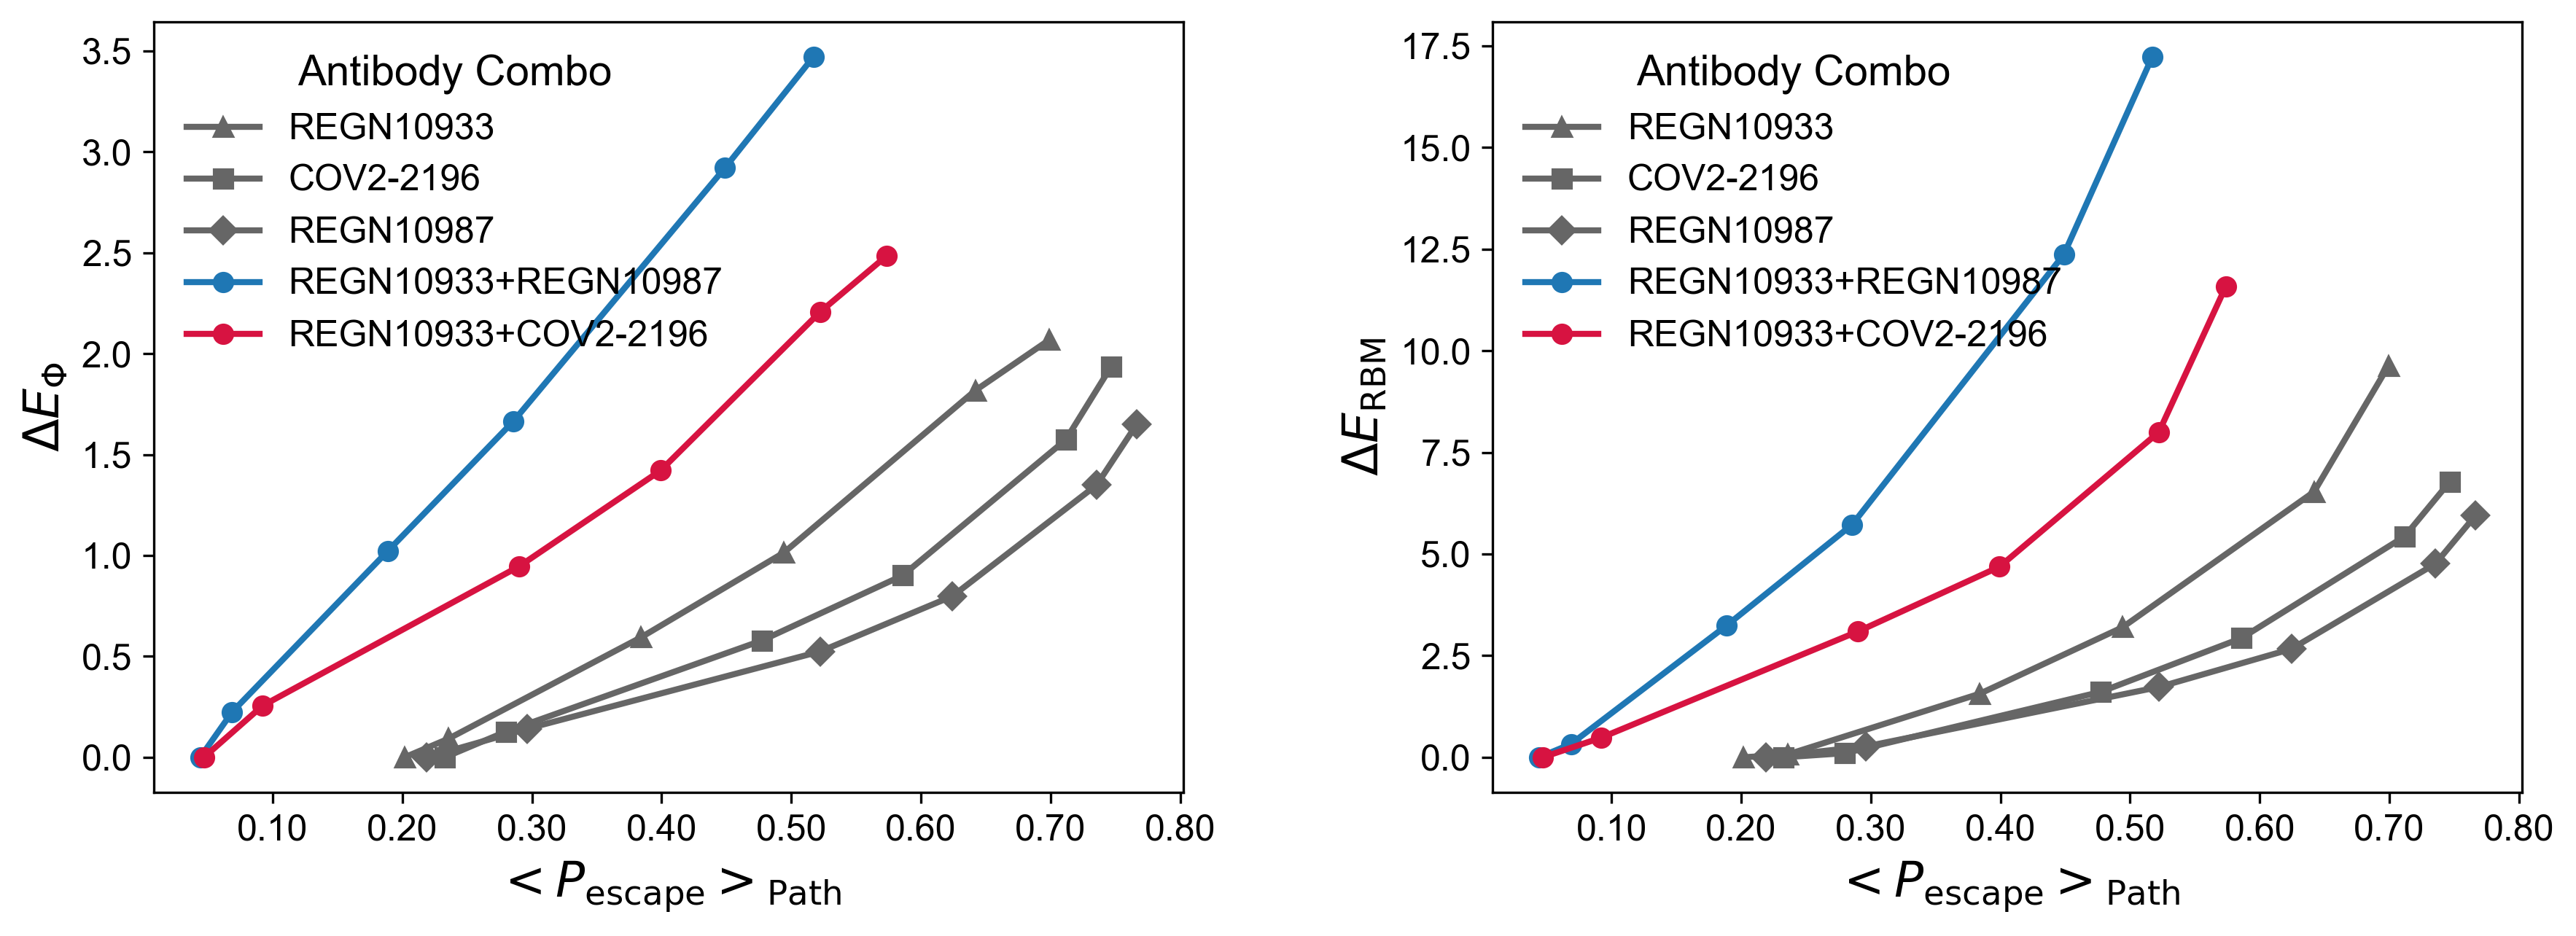

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import FormatStrFormatter

# Nature-style fonts and layout
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": "Arial",
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "lines.markersize": 6,
    "lines.linewidth": 2,
    "figure.dpi": 300
})
T=10
# Transform log prob to actual prob
df_plot = df.copy()
df_plot["p_escape"] = np.exp(-df_plot["zeta_ab"]*L/T)

# Features and labels
cost_features = ['delta_phi', 'delta_rbm']
latex_labels = [r'$\Delta E_{\Phi}$', r'$\Delta E_{\mathrm{RBM}}$']

# Define color and marker map
blue = '#1f77b4'
grey = '#666666'
red = "#d71341"

# Set mapping for color
color_map = {
    'REGN10933_REGN10987': blue,
    'REGN10933_COV2-2196': red
}

# Set mapping for markers
marker_map = {
    'REGN10933_REGN10987': 'o',
    'REGN10933_COV2-2196': 'o'
}

# Other antibodies: assign grey and different markers
other_markers = ['^', 's', 'D', 'P', 'v', 'X', '*', '<', '>']
other_idx = 0

# Find all unique combos
unique_combos = df_plot['ab_combo'].unique()

# Build color and marker map for all combos
for combo in unique_combos:
    if combo not in color_map:
        color_map[combo] = grey
        marker_map[combo] = other_markers[other_idx % len(other_markers)]
        other_idx += 1

# --- PLOT ---
fig, axes = plt.subplots(1, len(cost_features), figsize=(12, 4.5), sharey=False)

for i, (feature, label) in enumerate(zip(cost_features, latex_labels)):
    ax = axes[i]

    for combo in unique_combos:
        df_sub = df_plot[df_plot['ab_combo'] == combo]
        label_str = combo.replace('_', '+')

        df_sub_sorted = df_sub.sort_values(by=feature)
        ax.plot(
        df_sub_sorted['p_escape'],          # X
        df_sub_sorted[feature],             # Y
        marker=marker_map[combo],
        linestyle='-',
        color=color_map[combo],
        label=label_str
    )

    ax.set_xlabel(r'$<P_{\mathrm{escape}}>_{\mathrm{Path}}$')
    ax.set_ylabel(label)

    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.legend(title='Antibody Combo', frameon=False)

# Uniform layout
plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.show()


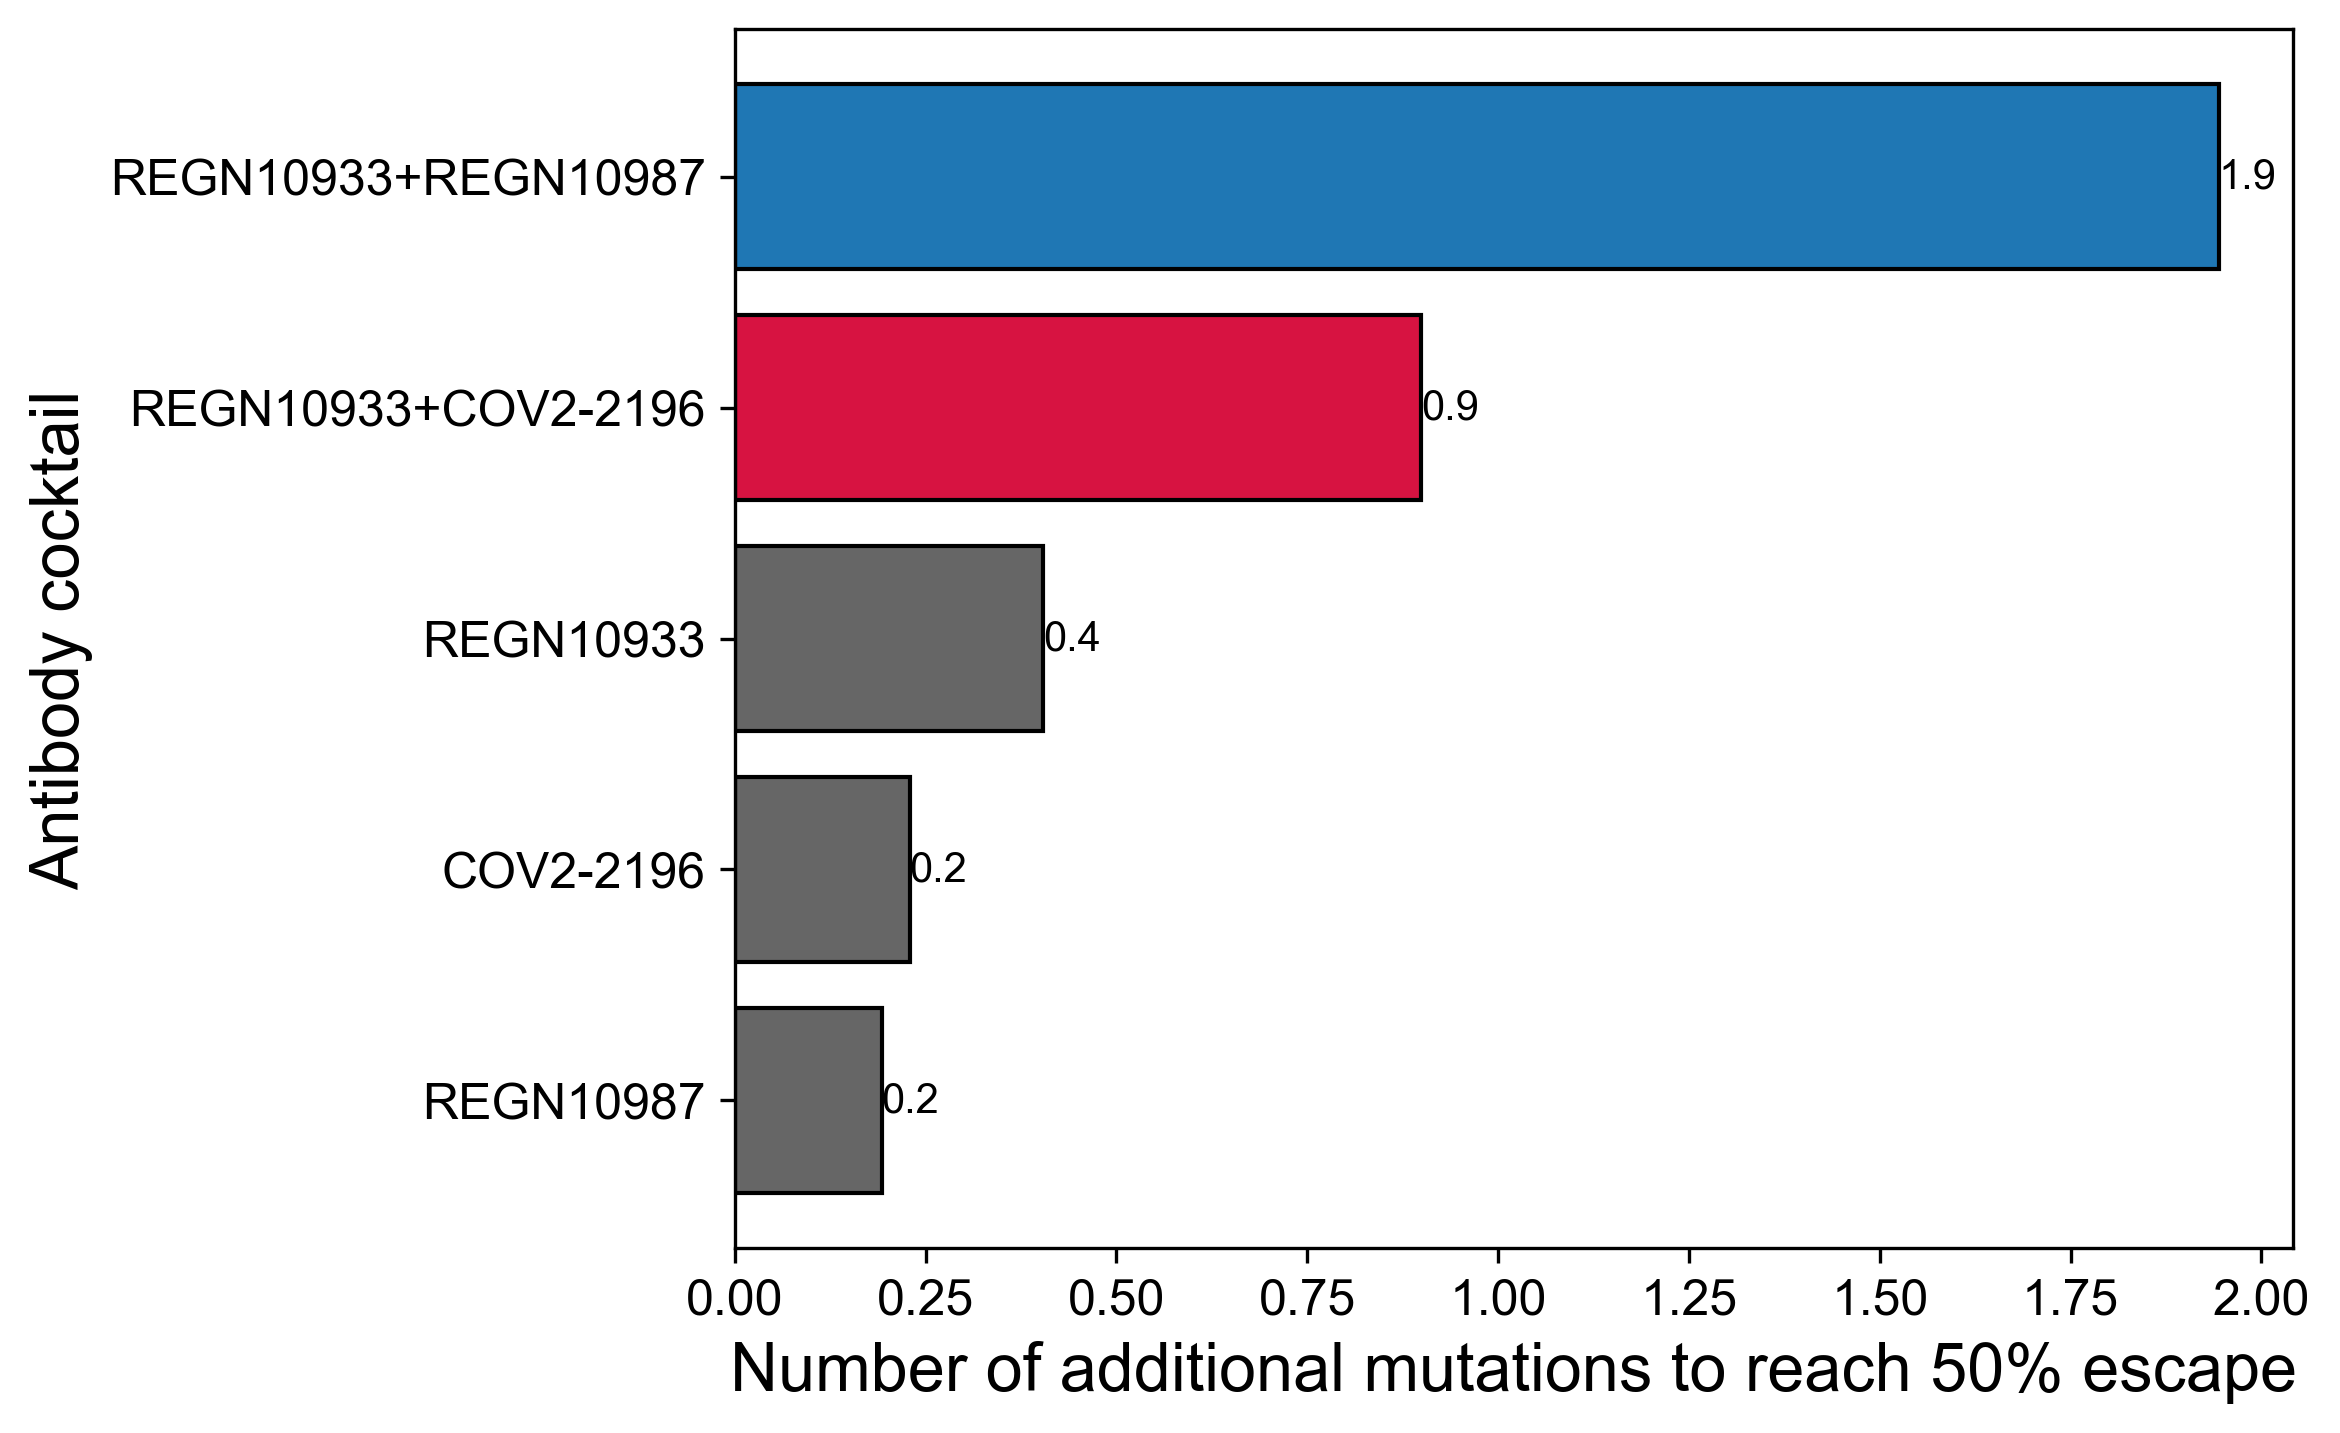

In [12]:
# --- CONFIG ---
TARGET_ESC = 0.50
E0 = 8.233626

# Collect nb_mutations = ΔE_RBM / E0 at p_escape = 0.5 via interpolation
results = []
skipped = []

for combo in unique_combos:
    df_sub = (
        df_plot[df_plot['ab_combo'] == combo]
        .dropna(subset=['p_escape', 'delta_rbm'])
        .sort_values('p_escape')
    )
    if df_sub.empty:
        skipped.append((combo, "no data"))
        continue

    x = df_sub['p_escape'].values
    y = df_sub['delta_rbm'].values

    # Need 0.5 to be within the observed range to safely interpolate
    if x.min() <= TARGET_ESC <= x.max():
        delta_at_50 = np.interp(TARGET_ESC, x, y)
        nb_mut = delta_at_50 / E0
        results.append((combo, nb_mut))
    else:
        skipped.append((combo, "does not bracket 0.5"))

# Warn in console if anything got skipped
if skipped:
    print("Skipped combos (reason):", skipped)

# Nothing to plot?
if not results:
    raise RuntimeError("No antibody combos bracket p_escape = 0.5; cannot interpolate.")

# Sort by value for a clean bar order (optional)
results.sort(key=lambda t: t[1])

labels = [c.replace('_', '+') for c, _ in results]
values = [v for _, v in results]
colors = [color_map.get(c, '#666666') for c, _ in results]

# --- PLOT: horizontal bar chart ---
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(labels, values, color=colors, edgecolor='black', linewidth=1)

ax.set_xlabel('Number of additional mutations to reach 50% escape')
ax.set_ylabel('Antibody cocktail')
# ax.set_title('# Mutations to reach 50% escape')
ax.grid(False)

# Optional: annotate bars with values
for b, v in zip(bars, values):
    ax.text(v, b.get_y() + b.get_height()/2,
            f'{v:.1f}', va='center', ha='left', fontsize=10)

plt.tight_layout()
plt.show()
